In [1]:
import scanpy as sc

#import stan.pp
from matplotlib import pyplot as plt

In [14]:
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams.update({'font.sans-serif': 'Helvetica'})
plt.rcParams.update({'font.size': 7})


In [3]:
adata_tf=sc.read("out/stf_results_tfa_only.h5ad")

         Falling back to preprocessing with `sc.pp.pca` and default params.


/Users/student/Library/Python/3.9/lib/python/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/Users/student/Library/Python/3.9/lib/python/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


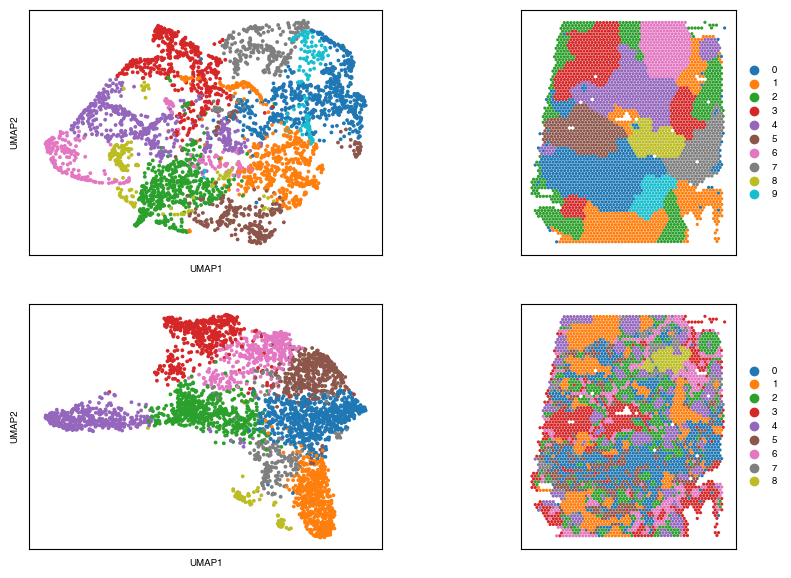

In [5]:
adata_tf=sc.read_h5ad("out/stf_results_tfa_only.h5ad")
sc.pp.scale(adata_tf)
sc.pp.neighbors(adata_tf, use_rep='X', n_neighbors=150)
sc.tl.leiden(adata_tf, resolution=0.7)
sc.tl.umap(adata_tf, min_dist=0.01)

adata = sc.read_h5ad("out/stf_results.h5ad")
sc.pp.neighbors(adata, n_neighbors=150)
sc.tl.leiden(adata, resolution=1.2)
sc.tl.umap(adata, min_dist=0.01)


fig, axs = plt.subplots(2,2, figsize=(10,7))

sc.pl.umap(adata, color="leiden", ax=axs[1,0], show=False, palette='')
sc.pl.spatial(adata, color='leiden', size=1.5, alpha_img=0, ax=axs[1,1], show=False)

sc.pl.umap(adata_tf, color="leiden", ax=axs[0,0], show=False)
sc.pl.spatial(adata_tf, color='leiden', alpha_img=0, size=1.5, ax=axs[0,1], show=False)


axs[1,1].set_ylabel("")
axs[1,1].set_xlabel("")
axs[1,1].set_title("")
axs[1,0].set_title("")

axs[0,1].set_ylabel("")
axs[0,1].set_xlabel("")
axs[0,1].set_title("")
axs[0,0].set_title("")

axs[0,0].legend().remove()
axs[1,0].legend().remove()

/Users/student/Library/Python/3.9/lib/python/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
meta NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


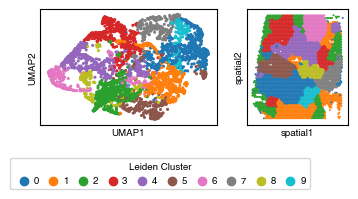

In [28]:
fig, axs = plt.subplots(1,2, figsize=(4,1.5), width_ratios=[2.5,1.5])
sc.pl.umap(adata_tf, color="leiden", ax=axs[0], show=False, s=20, palette='tab10')
sc.pl.spatial(adata_tf, color='leiden', alpha_img=0, size=2, ax=axs[1], show=False, palette='tab10')

for ax in axs.flatten():
    ax.set_ylabel(ax.get_ylabel(),labelpad=-1)
    ax.set_xlabel(ax.get_xlabel(),labelpad=-1)
    ax.set_title("")

axs[1].legend().remove()

axs[0].legend(title='Leiden Cluster', loc='lower left',bbox_to_anchor=(-0.2,-0.6), ncol=10, columnspacing=0.5, handletextpad=0)
plt.savefig("Clustering.pdf", bbox_inches='tight', pad_inches=0)

In [ ]:
fig, axs = plt.subplots(1,2, figsize=(6.5,1.8))
sc.pl.umap(adata_tf, color="leiden", ax=axs[0], show=False, s=20, palette='tab10')
sc.pl.spatial(adata_tf, color='leiden', alpha_img=0, size=2, ax=axs[1], show=False, palette='tab10')

sc.pl.umap(adata, color="leiden", ax=axs[2], show=False, s=20, palette="Set1")
sc.pl.spatial(adata, color='leiden', size=2, alpha_img=0, ax=axs[3], show=False, palette="Set1")


for ax in axs.flatten():
    ax.set_ylabel(ax.get_ylabel(),labelpad=-1)
    ax.set_xlabel(ax.get_xlabel(),labelpad=-1)
    ax.set_title("")

axs[1].legend().remove()
axs[3].legend().remove()

axs[0].legend(title='Leiden Cluster (TFA)', loc='lower left',bbox_to_anchor=(0,-0.5), ncol=5, columnspacing=1)
axs[2].legend(title='Leiden Cluster (mRNA)', loc='lower left',bbox_to_anchor=(0,-0.5), ncol=5, columnspacing=1)
plt.savefig("Clustering.pdf", bbox_inches='tight', pad_inches=0)

In [ ]:
plt.save_figure()

In [9]:
adata_tf.obsm['celltype'].groupby(adata_tf.obs['leiden']).mean()

,B_Cycling,B_GC_DZ,B_GC_LZ,B_GC_prePB,B_IFN,B_activated,B_mem,B_naive,B_plasma,B_preGC,...,T_CD4+_TfH,T_CD4+_TfH_GC,T_CD4+_naive,T_CD8+_CD161+,T_CD8+_cytotoxic,T_CD8+_naive,T_TIM3+,T_TfR,T_Treg,VSMC
leiden,,,,,,,,,,,,,,,,,,,,,
0,0.010254,0.005425,0.018756,0.003756,0.007532,0.050043,0.079931,0.167690,0.055611,0.038313,...,0.023909,0.018337,0.076607,0.012750,0.032190,0.020378,0.055883,0.012019,0.025788,0.024330
1,0.014276,0.004714,0.010033,0.004513,0.010896,0.032970,0.152947,0.088586,0.034657,0.057000,...,0.011434,0.014850,0.134301,0.008674,0.019089,0.019267,0.040695,0.015539,0.020443,0.033659
2,0.077639,0.017899,0.046653,0.015387,0.013239,0.023427,0.112040,0.093141,0.015450,0.051557,...,0.010769,0.039863,0.105966,0.007313,0.016051,0.014153,0.041862,0.014385,0.017236,0.017787
3,0.015147,0.006111,0.014874,0.006533,0.018552,0.020084,0.050696,0.075351,0.019386,0.038633,...,0.020365,0.016247,0.246617,0.011559,0.031391,0.041050,0.051106,0.028627,0.050911,0.021597
4,0.018196,0.007737,0.040322,0.007716,0.021260,0.033284,0.108196,0.210665,0.018972,0.046290,...,0.016895,0.035949,0.062573,0.008548,0.023258,0.012586,0.058762,0.014114,0.022505,0.017734
5,0.025129,0.005610,0.018576,0.006644,0.009339,0.026665,0.174545,0.105588,0.016970,0.051694,...,0.009361,0.023045,0.161502,0.006818,0.015461,0.017103,0.028428,0.014211,0.018464,0.020097
6,0.031271,0.005608,0.015591,0.006574,0.073392,0.014921,0.072926,0.046225,0.022553,0.075185,...,0.012067,0.015733,0.168884,0.008462,0.021548,0.025918,0.067266,0.022697,0.029793,0.021627
7,0.018524,0.007587,0.025417,0.005953,0.011620,0.044028,0.070260,0.158317,0.044577,0.037287,...,0.022895,0.020880,0.091965,0.012205,0.032288,0.021228,0.058344,0.014176,0.027843,0.021792
8,0.039542,0.015472,0.073635,0.014918,0.012711,0.032044,0.084135,0.189544,0.022120,0.031893,...,0.015893,0.046339,0.042727,0.008213,0.023429,0.009121,0.055805,0.012051,0.018676,0.016999


In [8]:
adata.obsm['celltype'].groupby(adata.obs['leiden']).mean()

,B_Cycling,B_GC_DZ,B_GC_LZ,B_GC_prePB,B_IFN,B_activated,B_mem,B_naive,B_plasma,B_preGC,...,T_CD4+_TfH,T_CD4+_TfH_GC,T_CD4+_naive,T_CD8+_CD161+,T_CD8+_cytotoxic,T_CD8+_naive,T_TIM3+,T_TfR,T_Treg,VSMC
leiden,,,,,,,,,,,,,,,,,,,,,
0,0.012932,0.005849,0.020281,0.004136,0.009786,0.048784,0.061953,0.165107,0.062786,0.040167,...,0.025455,0.017909,0.079779,0.013153,0.033373,0.021825,0.064336,0.013150,0.028431,0.023862
1,0.010568,0.005219,0.012067,0.006682,0.021550,0.013318,0.037719,0.057107,0.016323,0.033307,...,0.020852,0.014846,0.289882,0.012009,0.035604,0.046826,0.048939,0.033583,0.060283,0.020969
2,0.011266,0.006599,0.038966,0.006287,0.013101,0.033696,0.134803,0.254202,0.012579,0.045906,...,0.016671,0.038835,0.055466,0.007803,0.022580,0.009947,0.053126,0.013988,0.021891,0.015810
3,0.022057,0.004165,0.007737,0.003994,0.010272,0.030070,0.200554,0.080914,0.030839,0.064090,...,0.007260,0.014078,0.159393,0.006634,0.013030,0.016639,0.029046,0.012013,0.012431,0.028360
4,0.116726,0.030624,0.097043,0.027195,0.020897,0.020791,0.043388,0.107403,0.011674,0.023944,...,0.013330,0.068082,0.048497,0.007448,0.017775,0.008503,0.044408,0.011166,0.014794,0.013493
5,0.009323,0.005239,0.014948,0.003822,0.006672,0.050592,0.096600,0.138158,0.038431,0.041919,...,0.019826,0.014458,0.080305,0.012089,0.027699,0.018882,0.049020,0.012032,0.022092,0.028617
6,0.013394,0.004351,0.012213,0.005029,0.010193,0.032150,0.183713,0.099204,0.022025,0.066687,...,0.007925,0.016012,0.088149,0.007152,0.013560,0.010961,0.042343,0.013779,0.011584,0.029414
7,0.036140,0.004115,0.009340,0.004823,0.021334,0.021586,0.082643,0.060830,0.029661,0.093448,...,0.013545,0.013275,0.166225,0.009121,0.021974,0.027737,0.071406,0.020388,0.030791,0.022900
8,0.020187,0.003918,0.007188,0.004767,0.179105,0.004407,0.012976,0.010539,0.014053,0.039416,...,0.014845,0.009297,0.238021,0.009295,0.029918,0.036974,0.068570,0.028626,0.042560,0.017453


In [10]:
adata

AnnData object with n_obs × n_vars = 4013 × 8915
    obs: 'in_tissue', 'array_row', 'array_col', 'germinal_center', 'n_counts', 'ncounts', 'pixel_intensity', 'pred_cor_stl', 'pred_cor_stan', 'leiden', 'celltype'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells', 'fold', 'pred_cor_stl', 'pred_cor_stan'
    uns: 'spatial', 'tf_names', 'neighbors', 'leiden', 'umap', 'leiden_colors'
    obsm: 'celltype', 'celltype_raw', 'kernel', 'pixel_intensity', 'spatial', 'stan_tfa', 'stl_tfa', 'X_pca', 'X_umap'
    varm: 'tf_gene'
    layers: 'raw', 'scaled'
    obsp: 'kernel', 'pairwise_dists', 'distances', 'connectivities'

... storing 'celltype' as categorical


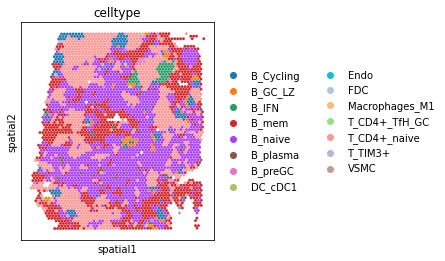

In [11]:
g = sns.FacetGrid(tips, col="time",  row="sex")
g.map(sns.scatterplot, "total_bill", "tip")

/var/folders/t6/876nj23922g7ync9x5slmd0h0000gq/T/ipykernel_67066/3269937733.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['cluster']=adata.obs['leiden']


/var/folders/t6/876nj23922g7ync9x5slmd0h0000gq/T/ipykernel_67066/4037067310.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['cluster']=adata_tf.obs['leiden']


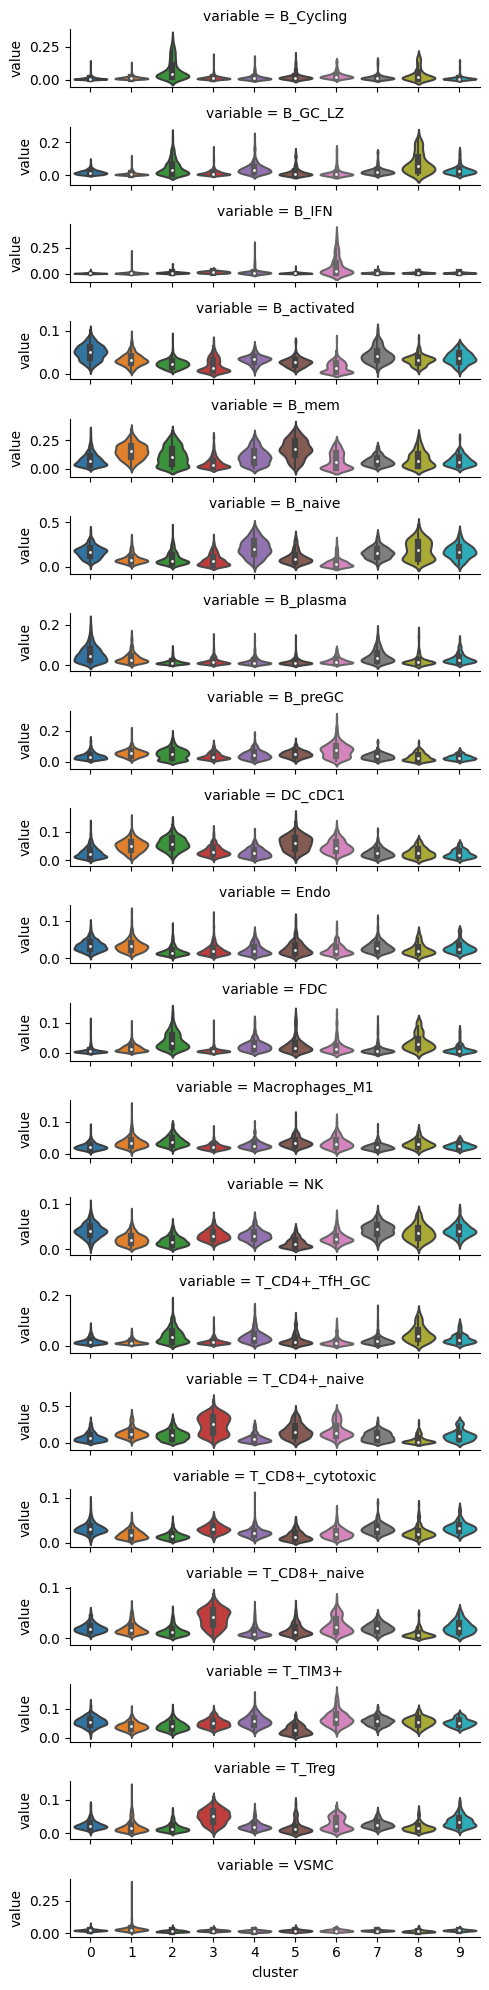

In [38]:
df=adata_tf.obsm["celltype"][adata_tf.obsm["celltype"].columns[adata_tf.obsm["celltype_raw"].mean()>0.5]]
df['cluster']=adata_tf.obs['leiden']
df=df.melt(id_vars="cluster")
import seaborn as sns
g = sns.FacetGrid(df, row="variable",hue='cluster', sharey=False, height=1, aspect=5)
g.map_dataframe(sns.violinplot, x="cluster", y="value")

/Users/student/Library/Python/3.9/lib/python/site-packages/scanpy/tools/_rank_genes_groups.py:420: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, 'logfoldchanges'] = np.log2(
/Users/student/Library/Python/3.9/lib/python/site-packages/scanpy/tools/_rank_genes_groups.py:420: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, 'logfoldchanges'] = np.log2(
/Users/student/Library/Python/3.9/lib/python/site-packages/scanpy/tools/_rank_genes_groups.py:420: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, 'logfoldchanges'] = np.log2(
/Users/student/Library/Python/3.9/lib/python/site-packages/scanpy/tools/_rank_genes_groups.py:420: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, 'logfoldchanges'] = np.log2(
/Users/student/Library/Python/3.9/lib/python/site-packages/scanpy/tools/_rank_genes_groups.py:420: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, 'logfoldchange

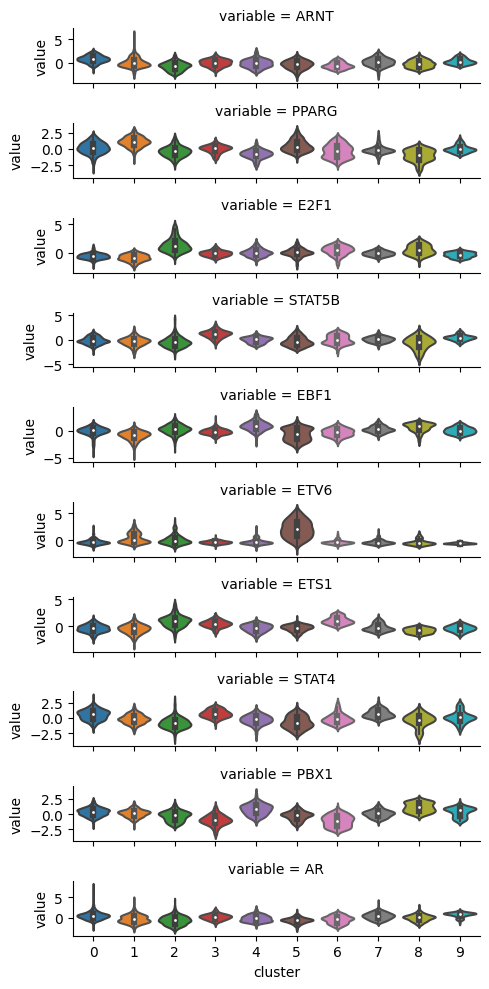

In [81]:
sc.tl.rank_genes_groups(adata_tf, 'leiden', method='wilcoxon')
df=adata_tf.to_df()[[*adata_tf.uns["rank_genes_groups"]['names'][0]]]
df['cluster']=adata_tf.obs['leiden']
df=df.melt(id_vars="cluster")
import seaborn as sns
g = sns.FacetGrid(df, row="variable",hue='cluster', sharey=False, height=1, aspect=5)
g.map_dataframe(sns.violinplot, x="cluster", y="value")

In [ ]:
sc.tl.rank_genes_groups(adata_tf, 'leiden', method='wilcoxon')
df=adata_tf.to_df()[[*adata_tf.uns["rank_genes_groups"]['names'][0], *adata_tf.uns["rank_genes_groups"]['names'][1],*adata_tf.uns["rank_genes_groups"]['names'][3]]]
df['cluster']=adata_tf.obs['leiden']
df=df.melt(id_vars="cluster")
import seaborn as sns
g = sns.FacetGrid(df, row="variable",hue='cluster', sharey=False, height=1, aspect=5)
g.map_dataframe(sns.violinplot, x="cluster", y="value")

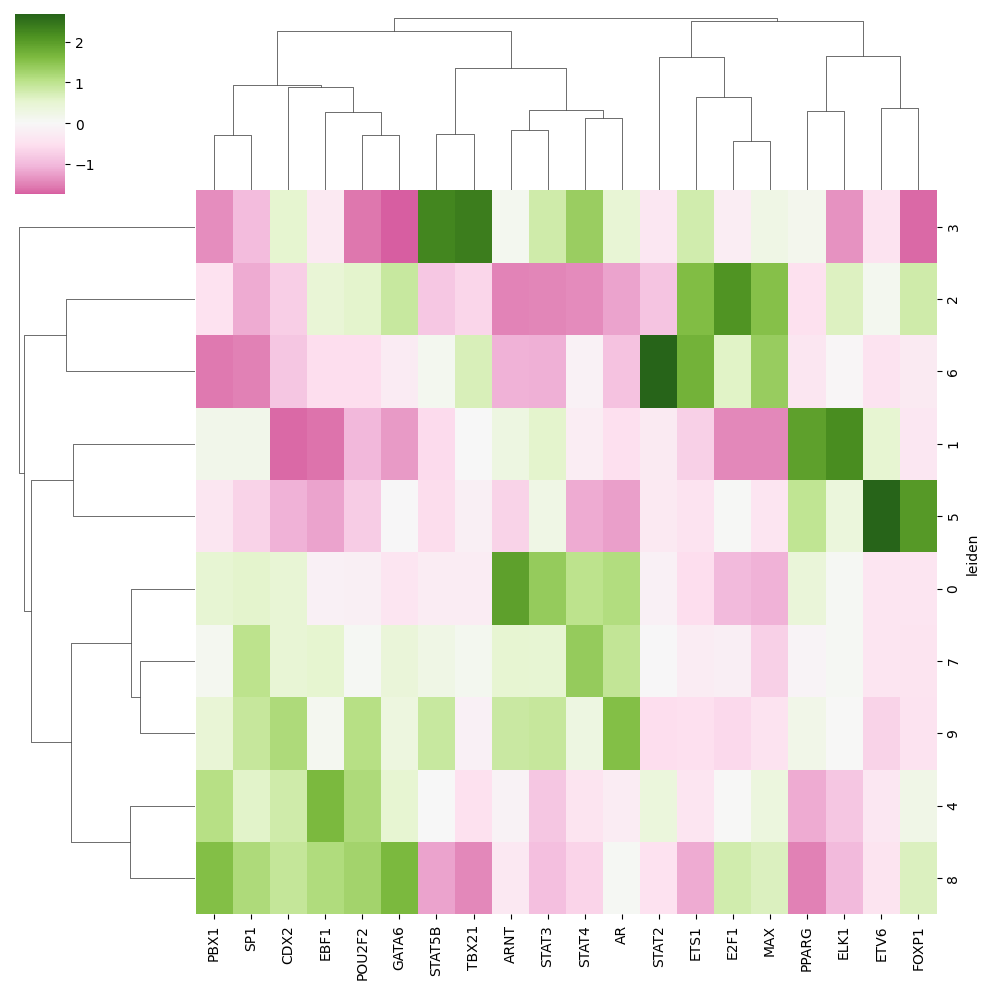

In [76]:
df=adata_tf.to_df()[[*adata_tf.uns["rank_genes_groups"]['names'][0], *adata_tf.uns["rank_genes_groups"]['names'][1]]].groupby(adata_tf.obs['leiden']).mean()
sns.clustermap(df, cmap='PiYG', center=0, z_score=1)

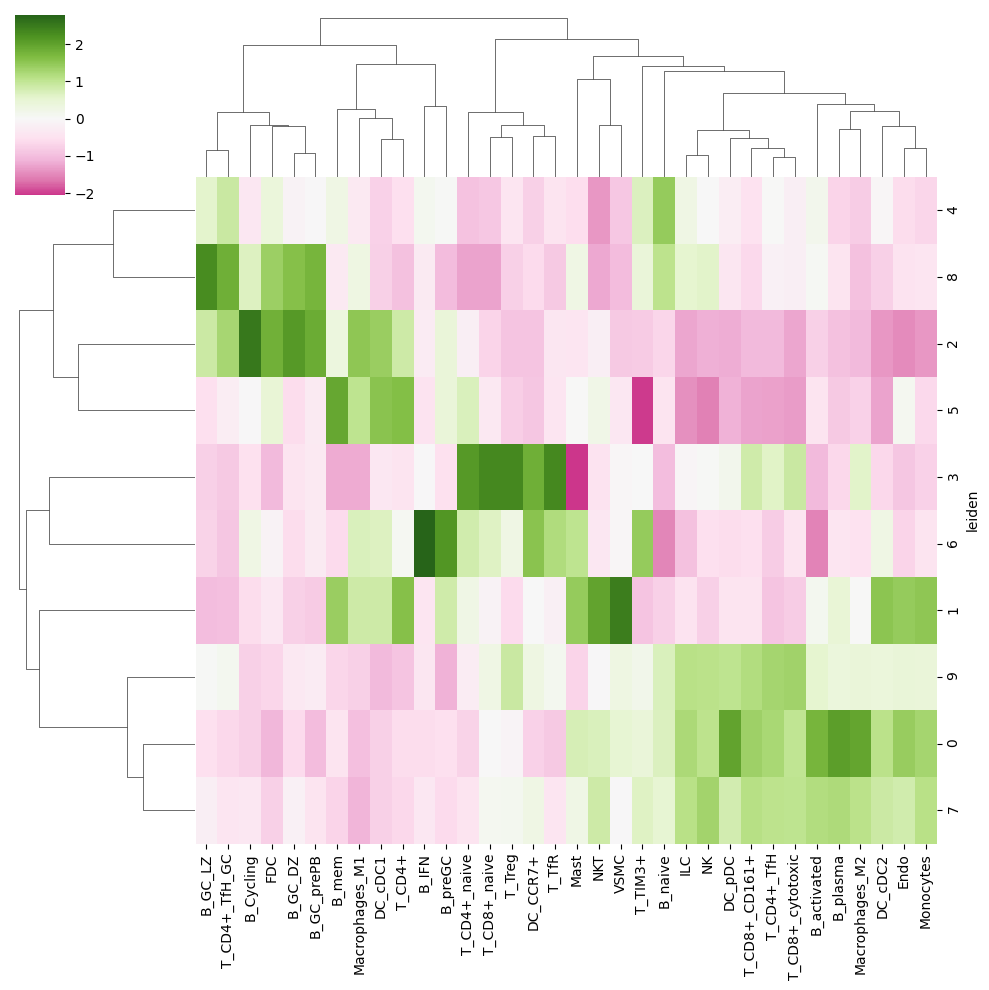

In [80]:
df=adata_tf.obsm["celltype"].groupby(adata_tf.obs['leiden']).mean()
sns.clustermap(df, cmap='PiYG', center=0, z_score=1)

In [48]:
sc.tl.rank_genes_groups(adata_tf, 'leiden', method='wilcoxon')

/Users/student/Library/Python/3.9/lib/python/site-packages/scanpy/tools/_rank_genes_groups.py:420: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, 'logfoldchanges'] = np.log2(
/Users/student/Library/Python/3.9/lib/python/site-packages/scanpy/tools/_rank_genes_groups.py:420: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, 'logfoldchanges'] = np.log2(
/Users/student/Library/Python/3.9/lib/python/site-packages/scanpy/tools/_rank_genes_groups.py:420: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, 'logfoldchanges'] = np.log2(
/Users/student/Library/Python/3.9/lib/python/site-packages/scanpy/tools/_rank_genes_groups.py:420: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, 'logfoldchanges'] = np.log2(
/Users/student/Library/Python/3.9/lib/python/site-packages/scanpy/tools/_rank_genes_groups.py:420: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, 'logfoldchange

In [12]:
sns.boxplot(x=adata_tf.obs['leiden'], y=adata_tf.obsm['celltype']['B_mem'])
sns.boxplot(x=adata_tf.obs['leiden'], y=adata_tf.obsm['celltype']['B_naive'])
sns.boxplot(x=adata_tf.obs['leiden'], y=adata_tf.obsm['celltype']['B_naive'])

celltype,B_Cycling,B_GC_LZ,B_IFN,B_mem,B_naive,B_plasma,B_preGC,DC_cDC1,Endo,FDC,Macrophages_M1,T_CD4+_TfH_GC,T_CD4+_naive,T_TIM3+,VSMC
leiden,,,,,,,,,,,,,,,
0,0,0,0,39,433,17,3,0,1,0,0,0,89,1,0
1,2,4,1,172,320,0,3,0,0,0,0,1,34,0,0
2,2,0,0,10,75,1,2,0,0,0,0,0,446,0,0
3,1,0,10,352,34,8,4,2,1,0,1,0,88,0,2
4,148,67,0,81,82,0,1,0,0,2,0,6,74,0,0
5,2,0,0,158,28,1,2,0,0,0,0,0,117,0,0
6,3,2,0,15,189,3,2,0,0,0,0,0,77,1,0
7,4,0,42,26,67,3,11,0,0,0,0,0,100,3,0
8,0,0,0,50,140,3,0,0,0,0,0,0,22,0,0


<AxesSubplot:xlabel='leiden', ylabel='B_naive'>

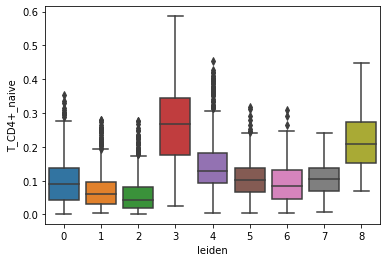

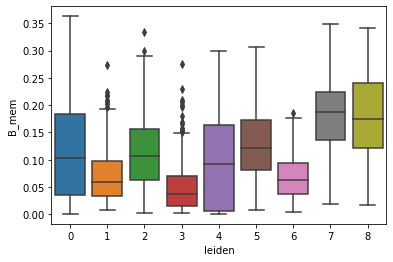

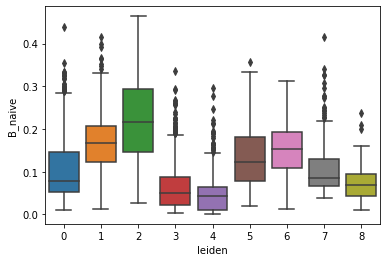

In [16]:
sns.boxplot(x=adata_tf.obs['leiden'], y=adata_tf.obsm['celltype']['T_CD4+_naive'])
plt.figure()
sns.boxplot(x=adata_tf.obs['leiden'], y=adata_tf.obsm['celltype']['B_mem'])
plt.figure()
sns.boxplot(x=adata_tf.obs['leiden'], y=adata_tf.obsm['celltype']['B_naive'])

<AxesSubplot:xlabel='leiden', ylabel='B_naive'>

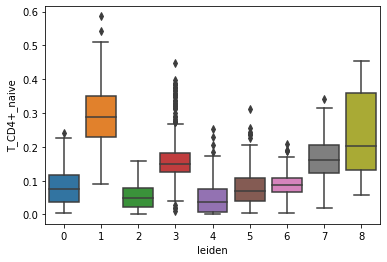

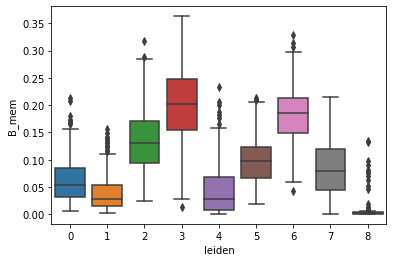

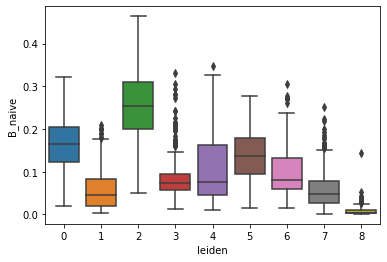

In [15]:
import seaborn as sns
sns.boxplot(x=adata.obs['leiden'], y=adata.obsm['celltype']['T_CD4+_naive'])
plt.figure()
sns.boxplot(x=adata.obs['leiden'], y=adata.obsm['celltype']['B_mem'])
plt.figure()
sns.boxplot(x=adata.obs['leiden'], y=adata.obsm['celltype']['B_naive'])

In [10]:
adata_tf.obs.groupby(['leiden', 'germinal_center']).size().unstack(fill_value=0)

germinal_center,0,1
leiden,,
0,510,287
1,655,2
2,545,47
3,587,2
4,372,10
5,288,3
6,258,1
7,251,2
8,155,14


In [11]:
adata.obs.groupby(['leiden', 'celltype']).size().unstack(fill_value=0)

KeyError: 'celltype'

<AxesSubplot:xlabel='leiden', ylabel='B_mem'>

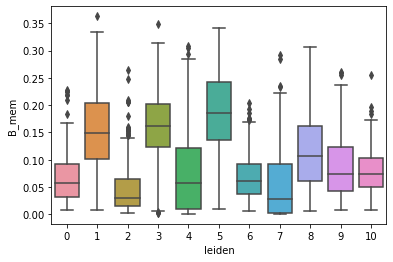

In [16]:
import seaborn as sns
sns.boxplot(x=adata_tf.obs['leiden'], y=adata_tf.obsm['celltype']['B_mem'])

<AxesSubplot:xlabel='leiden', ylabel='B_mem'>

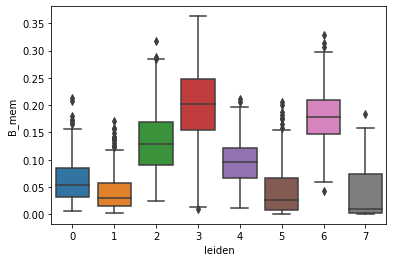

In [33]:
sns.boxplot(x=adata.obs['leiden'], y=adata.obsm['celltype']['B_GC_DZ'])

NameError: name 'adata' is not defined

<AxesSubplot:xlabel='leiden', ylabel='B_mem'>

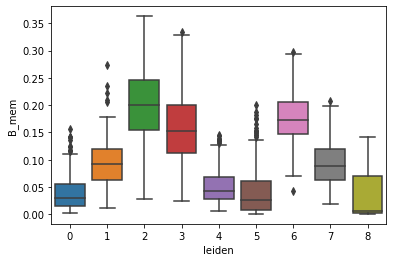

In [127]:
sns.boxplot(x=adata.obs['leiden'], y=adata_tf.obsm['celltype']['B_mem'])

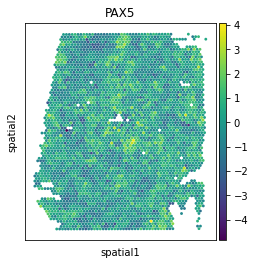

In [124]:
sc.pl.spatial(adata_tf, color='PAX5', size=1.5, alpha_img=0)

<AxesSubplot:>

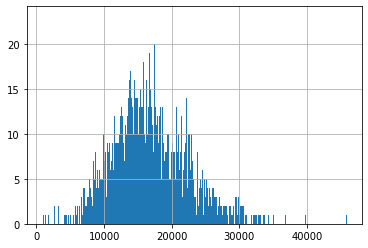

In [8]:
adata.to_df('raw').T.sum().hist(bins=1000)

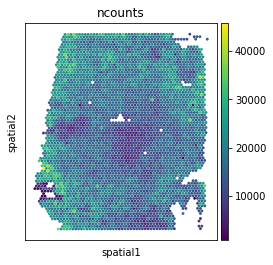

In [9]:
adata.obs['ncounts']=adata.to_df('raw').T.sum()
sc.pl.spatial(adata, color='ncounts', size=1.5, alpha_img=0)